<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK4_study_0406.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##4.3 앙상블 학습
(p.210 ~ 244)

###앙상블 학습 개요
- 앙상블 학습(Ensemble Learning)을 통한 분류
  - 여러 개의 분류기(Classifier)를 생성하고
  - 그 예측을 결합함으로써
  - 보다 정확한 최종 예측을 도출하는 기법
- 목표
  - 다양한 분류기의 예측 결과를 결합함으로써 단일 분류기보다 신뢰성이 높은 예측값을 얻는 것
- 정형 데이터 분류 시 뛰어난 성능
- 랜덤 포레스트, 그래디언트 부스팅 알고리즘 애용
- XGBoost, LightGBM, 스태킹 등 인기

- 앙상블 학습의 유형
  - 보팅(Voting), 배깅(Bagging): 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식
    - 보팅: 서로 다른 알고리즘을 가진 분류기를 결합
    - 배깅: 각각의 분류기가 모두 같은 유형의 알고리즘 기반이지만, 샘플링을 서로 다르게 가져가면서 학습을 수행해 보팅을 수행
      - 대표적인 방식: 랜덤 포레스트 알고리즘.
      - 부트스트래핑(Bootstrapping) 분할 방식: 개별 Classifier에게 데이터를 샘플링해서 추출하는 방식
      - 개별 분류기가 부트스트래핑 방식으로 샘플링된 데이터 세트에 대해서 학습을 통해 개별적인 예측을 수행한 결과를 보팅을 통해서 최종 결과를 선정하는 방식
      - 중첩 허용
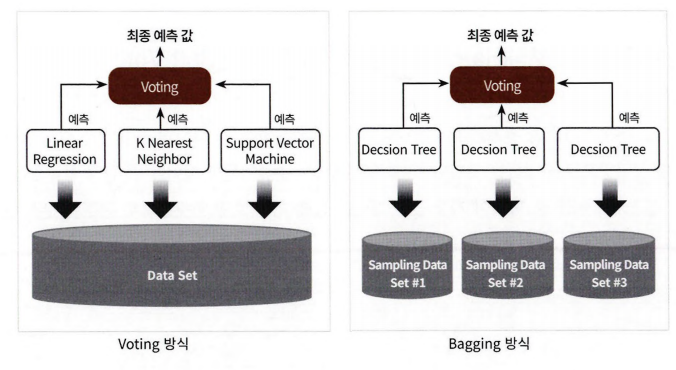
  - 부스팅(Boosting)
    - 여러 개의 분류기가 순차적으로 학습을 수행하되, 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에게는 가중치(weight)를 부여하면서 학습과 예측을 진행하는 것
    - 대표적인 모듈: 그래디언트 부스트, XGBoost(eXtra Gradient Boost), LightGBM(Light Gradient Boost)

###보팅 유형 - 하드 보팅(Hard Voting)과 소프트 보팅(Soft Voting)
- 하드 보팅
  - 다수결 원칙과 비슷
  - 예측한 결과값 중 다수의 분류기가 결정한 예측값을 최종 보팅 결과값으로 선정하는 것
- 소프트 보팅
  - 분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균해서 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결과값으로 선정.
  - 예측 성능이 좋아서 더 많이 사용됨.
  - 클래스1: (0.7+0.2+0.8+0.9)/4 = 0.65
  - 클래스2: (0.3+0.8+0.2+0.1)/4 = 0.35
  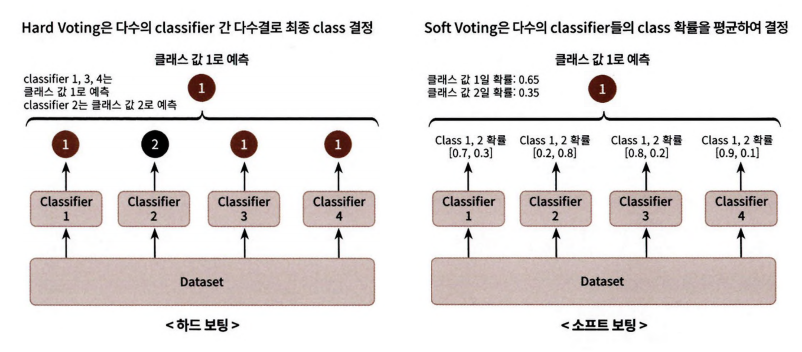

###보팅 분류기(Voting Classifier)
- 보팅 방식의 앙상블을 이용한 위스콘신 유방암 데이터 세트 예측 분석
- 유방암의 악성종양 / 양성종양 영부를 결정하는 이진 분류 데이터 세트
- 피처: 종양의 크기, 모양 등
- load_breast_cancer() 함수 -> 자체에서 생성 가능

In [2]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [3]:
# 개별 모델은 로지스틱 회귀와 KNN임.
Ir_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', Ir_clf), ('KNN', knn_clf)], voting='soft')
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# VotingClassifier 학습/예측/평가.
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가.
classifiers = [Ir_clf, knn_clf]
for classifier in classifiers:
  classifier.fit(X_train, y_train)
  pred = classifier.predict(X_test)
  class_name = classifier.__class__.__name__
  print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


- 어떻게 높은 유연성을 가지고 현실에 대처할 수 있는가가 중요한 ML 모델의 평가요소
- 편향-분산 트레이드오프 극복 과제
  - 배깅과 부스팅은 대부분 결정 트리 알고리즘 기반
  - 수십~수천 개의 매우 많은 분류기를 결합해 다양한 상황을 학습하게 함으로써 과적합 극복

##4.4 랜덤 포레스트

###랜덤 포레스트의 개요 및 실습
- 배깅(bagging): 같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 최종 결정하는 알고리즘
- 랜덤 포레스트는 대표적인 배깅 알고리즘.
- 결정 트리 기반
  - 여러 개의 결정 트리 분류기가
  - 전체 데이터에서 배깅 방식으로 각자의 데이터를 샘플링해 개별적으로 학습을 수행한 뒤
  - 최종적으로 모든 분류기가 보팅을 통해 예측 결정을 하게 됨.
  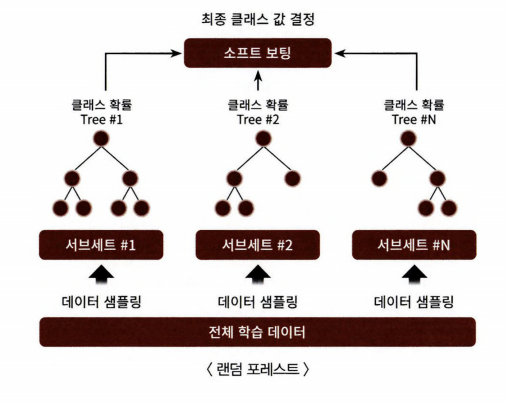

- 부트스트래핑(bootstrapping) 분할 방식
  - 개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 샘플링된 데이터 세트
  - 랜덤 포레스트의 Subset 데이터는 부트스트래핑으로 데이터가 임의로 만들어짐.
  - 서브세트의 데이터 건수는 전체 데이터 건수와 동일. 개별 데이터가 중첩되게 만들어짐.
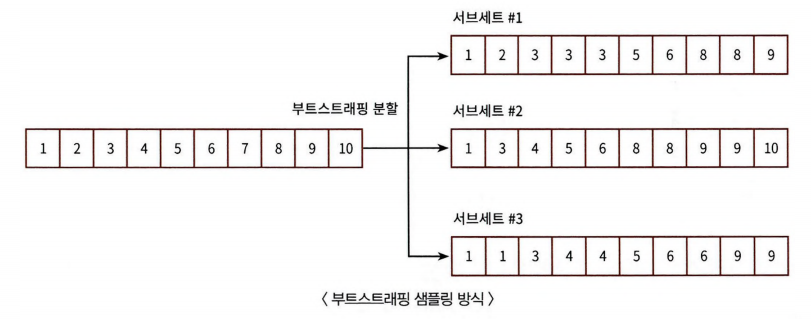

- 랜덤 포레스트: 데이터가 중첩된 개별 데이터 세트에 결정 트리 분류기를 각각 적용하는 것
- RandomForestClassifier
- random_state = 0: 재수행할 때마다 동일한 예측 결과 출력

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 코드 추가
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df=pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
  feature_dup_df=feature_dup_df.reset_index()
  new_feature_name_df=pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name']=new_feature_name_df[['column_name','dup_cnt']].apply(lambda x: x[0]+'_'+str(x[1]) if x[1]>0 else x[0], axis=1)
  new_feature_name_df=new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

def get_human_dataset():
  feature_name_df = pd.read_csv('features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
  new_feature_name_df = get_new_feature_name_df(feature_name_df)
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
  X_train = pd.read_csv('X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('X_test.txt', sep='\s+', names=feature_name)
  y_train = pd.read_csv('y_train.txt', sep='\s+', header=None, names=['action'])
  y_test = pd.read_csv('y_test.txt', sep='\s+', header=None, names=['action'])
  return X_train, X_test, y_train, y_test

# 결정 트리에서 사용한 get_human_dataset()를 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9220


###랜덤 포레스트 하이퍼 파라미터 및 튜닝
- 트리 기반의 앙상블 알고리즘의 단점
  - 하이퍼 파라미터가 너무 많음.
  - 그로 인한 튜닝 시간이 많이 소모됨.
  - 튜닝 후 예측 성능이 크게 향상되는 경우가 많지 않음.

####랜덤 포레스트 하이퍼 파라미터
- n_estimators
  - 랜덤 포레스트에서 결정 트리의 개수를 지정.
  - 디폴트는 10개.
  - 많이 설정할수록 좋은 성능을 기대할 수 있지만 계속 증가시킨다고 성능이 무조건 향상되는 것은 아님.
  - 늘릴수록 수행 시간이 오래걸림.
- max_features
  - 'None'이 아니라 'auto', 즉 'sqrt'와 같음.
  - 랜덤 포레스트의 트리를 분할하는 피처를 참조할 때 전체 피처가 아니라 sqrt(전체 피처 개수)만큼 참조함.
  - 전체 피처가 16개라면 분할을 위해 4개 참조.
- max_depth, min_samples_leat, min_samples_split
  - 결정트리에서 과적합을 개선하기 위해 사용됨.

####랜덤 포레스트 하이퍼 파라미터 튜닝

In [8]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [8, 16, 24],
    'min_samples_leaf': [1, 6, 12],
    'min_samples_split': [2, 8, 16]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 16, 'min_samples_leaf': 6, 'min_samples_split': 16}
최고 예측 정확도: 0.9157


In [9]:
# 다시 RandomForestClassifier를 학습시킨 뒤에, 별도의 테스트 데이터 세트에서 예측 성능 측정
rf_clf1 = RandomForestClassifier(n_estimators=100, min_samples_leaf=6, max_depth=16,
                                 min_samples_split=2, random_state=0)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9253


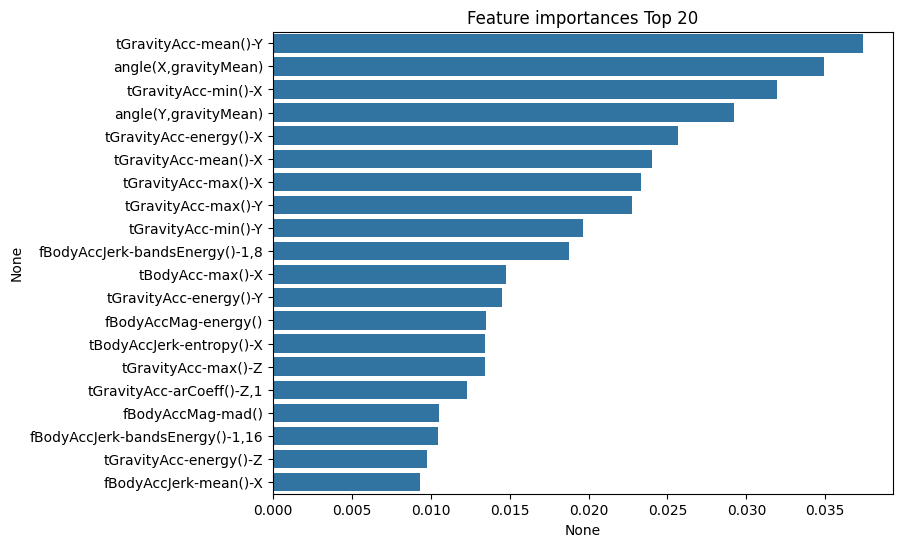

In [10]:
# 피처 중요도를 막대그래프로 시각화
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

##4.5 GBM(Gradient Boosting Machine)


###GBM의 개요 및 실습
- 부스팅 알고리즘
  - 여러 개의 약한 학습기를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식
  - 대표적인 구현: AdaBoost(Adaptive boosting), 그래디언트 부스트

####에이다 부스트(AdaBoost)
- 오류 데이터에 가중치를 부여하면서 부스팅을 수행
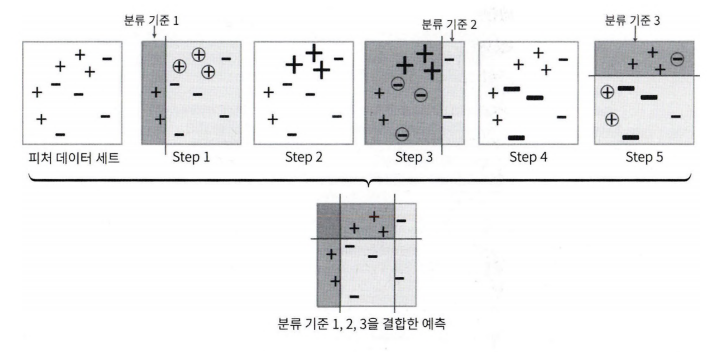

가중치 부여
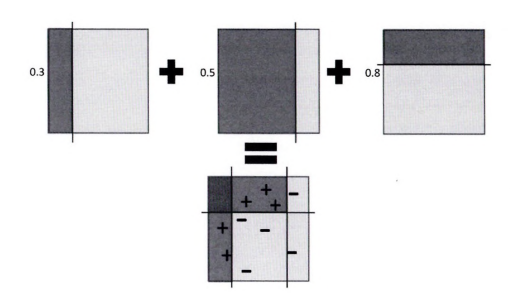

####GBM(Gradient Boost Machine)
- 가중치 업데이트를 경사 하강법(Gradient Descent)을 이용하는 것이 큰 차이
- 오류 값 = 실제 값 - 예측값
  $$h(x) = y - F(x)$$
  - 이 오류식을 최소화하는 방향성을 가지고 반복적으로 가중치 값을 업데이트하는 것 = 경사 하강법

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f}초'.format(time.time() - start_time))

GBM 정확도: 0.9379
GBM 수행 시간: 2050.9초


- GBM이 랜덤포레스트보다는 예측 성능이 조금 뛰어남.
- But 수행 시간이 오래 걸리고, 하이퍼 파라미터 튜닝 노력도 더 필요함.

###GBM 하이퍼 파라미터 소개
- loss
  - 경사 하강법에서 사용할 비용 함수를 지정.
  - 기본값은 'deviance'.
- learning_rate
  - GBM이 학습을 진행할 때마다 적용하는 학습률
  - Weak learner가 순차적으로 오류 값을 보정해 나가는 데 적용하는 계수
  - 0~1 사이의 값을 지정할 수 있으며 기본값은 0.1.
  - 너무 작은 값을 적용하면 업데이트되는 값이 작아져서 최소 오류 값을 찾아 예측 성능이 높아질 가능성이 높음.
  - 너무 크면 예측 성능이 떨어질 가능성은 높지만 빠른 수행 가능.
  - n_estimators와 상호 보완적으로 조합해 사용.
    - learning_rate를 작게 하고 n_estimators를 크게 하면 더 이상 성능이 좋아지지 않는 한계점까지는 예측 성능이 조금씩 좋아짐.
- n_estimators
  - weak learner의 개수
  - weak learner가 순차적으로 오류를 보정하므로 개수가 많을수록 예측 성능이 일정 수준까지는 좋아짐.
  - 개수가 많을수록 수행 시간이 오래 걸림.
  - 기본값: 100
- subsample
  - weak learner가 학습에 사용하는 데이터의 샘플링 비율
  - 기본값: 1. 전체 학습 데이터를 기반으로 학습한다는 의미(0.5이면 학습 데이터의 50%).
  - 과적합이 염려되는 경우 subsample을 1보다 작은 값으로 설정


##4.6 XGBoost(eXtra Gradient Boost)
- 트리 기반의 앙상블 학습에서 가장 각광받고 있는 알고리즘.
- 장점
  - 뛰어난 예측 성능
  - GBM 대비 빠른 수행 시간
  - 과적합 규제 (Regularization)
  - Tree pruning (나무 가지치기)
  - 자체 내장된 교차 검증
  - 결손값 자체 처리
- 파이썬 래퍼 XGBoost 모듈
  - fit(), predict() 불가
- 사이킷런 래퍼 XGBoost 모듈
  - fit(), predict() 가능
  - 사이킷런 래퍼 클래스: XGBClassifier & XGBRegressor

###XGBoost 설치하기

In [13]:
pip install xgboost==1.5.0

In [14]:
import xgboost as xgb
from xgboost import XGBClassifier

###파이썬 래퍼 XGBoost 하이퍼 파라미터
- GBM과 유사한 하이퍼 파라미터를 동일하게 가지고 있음.
- 조기 중단, 과적합을 규제하기 위한 하이퍼 파라미터가 추가됨.

<파이썬 래퍼 하이퍼 파라미터>
- 일반 파라미터
  - 일반적으로 실행 시 스레드의 개수나 silent 모드 등의 선택을 위한 파라미터
  - 디폴트 파라미터 값을 바꾸는 경우는 거의 없음.
- 부스터 파라미터
  - 트리 최적화, 부스팅, regularization 등과 같은 파라미터
  - 대부분의 파라미터는 여기 속함.
- 학습 테스크 파라미터
  - 학습 수행 시의 객체 함수, 평가를 위한 지표 등을 설명하는 파라미터

####주요 일반 파라미터
* **booster**: gbtree(tree based model) 또는 gblinear(linear model) 선택. 디폴트는 gbtree입니다.
* **silent**: 디폴트는 0이며, 출력 메시지를 나타내고 싶지 않을 경우 1로 설정합니다.
* **nthread**: CPU의 실행 스레드 개수를 조정하며, 디폴트는 CPU의 전체 스레드를 다 사용하는 것입니다. 멀티 코어/스레드 CPU 시스템에서 전체 CPU를 사용하지 않고 일부 CPU만 사용해 ML 애플리케이션을 구동하는 경우에 변경합니다.

---

#### 주요 부스터 파라미터

* **eta** [default=0.3, alias: learning_rate]: GBM의 학습률(learning rate)과 같은 파라미터입니다. 0에서 1 사이의 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값. 파이썬 래퍼 기반의 xgboost를 이용할 경우 디폴트는 0.3. 사이킷런 래퍼 클래스를 이용할 경우 eta는 learning_rate 파라미터로 대체되며, 디폴트는 0.1입니다. 보통은 0.01 ~ 0.2 사이의 값을 선호합니다.
* **num_boost_rounds**: GBM의 n_estimators와 같은 파라미터입니다.
* **min_child_weight** [default=1]: 트리에서 추가적으로 가지를 나눌지를 결정하기 위해 필요한 데이터들의 weight 총합. min_child_weight이 클수록 분할을 자제합니다. 과적합을 조절하기 위해 사용됩니다.
* **gamma** [default=0, alias: min_split_loss]: 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값입니다. 해당 값보다 큰 손실(loss)이 감소된 경우에 리프 노드를 분리합니다. 값이 클수록 과적합 감소 효과가 있습니다.
* **max_depth** [default=6]: 트리 기반 알고리즘의 max_depth와 같습니다. 0을 지정하면 깊이에 제한이 없습니다. Max_depth가 높으면 특정 피처 조건에 특화되어 룰 조건이 만들어지므로 과적합 가능성이 높아지며 보통은 3~10 사이의 값을 적용합니다.
* **sub_sample** [default=1]: GBM의 subsample과 동일합니다. 트리가 커져서 과적합되는 것을 제어하기 위해 데이터를 샘플링하는 비율을 지정합니다. sub_sample=0.5로 지정하면 전체 데이터의 절반을 트리를 생성하는 데 사용합니다. 0에서 1 사이의 값이 가능하나 일반적으로 0.5 ~ 1 사이의 값을 사용합니다.
* **colsample_bytree** [default=1]: GBM의 max_features와 유사합니다. 트리 생성에 필요한 피처(칼럼)를 임의로 샘플링하는 데 사용됩니다. 매우 많은 피처가 있는 경우 과적합을 조정하는 데 적용합니다.
* **lambda** [default=1, alias: reg_lambda]: L2 Regularization 적용 값입니다. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있습니다.
* **alpha** [default=0, alias: reg_alpha]: L1 Regularization 적용 값입니다. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있습니다.
* **scale_pos_weight** [default=1]: 특정 값으로 치우친 비대칭한 클래스로 구성된 데이터 세트의 균형을 유지하기 위한 파라미터입니다.

---

#### 학습 태스크 파라미터

* **objective**: 최솟값을 가져야 할 손실 함수를 정의합니다. XGBoost는 많은 유형의 손실함수를 사용할 수 있습니다. 주로 사용되는 손실함수는 이진 분류인지 다중 분류인지에 따라 달라집니다.
* **binary:logistic**: 이진 분류일 때 적용합니다.
* **multi:softmax**: 다중 분류일 때 적용합니다. 손실함수가 multi:softmax일 경우에는 레이블 클래스의 개수인 num_class 파라미터를 지정해야 합니다.
* **multi:softprob**: multi:softmax와 유사하나 개별 레이블 클래스의 해당되는 예측 확률을 반환합니다.
* **eval_metric**: 검증에 사용되는 함수를 정의합니다. 기본값은 회귀인 경우는 rmse, 분류일 경우에는 error입니다. 다음은 eval_metric의 값 유형입니다.
  * rmse: Root Mean Square Error
  * mae: Mean Absolute Error
  * logloss: Negative log-likelihood
  * error: Binary classification error rate (0.5 threshold)
  * merror: Multiclass classification error rate
  * mlogloss: Multiclass logloss
  * auc: Area under the curve

####과적합 문제가 심할 때
- eta 값 ↓ (0.01~0.1). num_round(또는 n_estimators) ↑
- max_depth 값 ↓
- min_child_weight ↑
- gamma ↑
- subsample과 colsample_bytree 조정

####성능 향상
- 조기 중단(Early Stopping): 수행 속도 향상
  - n_estimators에 지정된 횟수만큼 반복적으로 학습 오류를 감소시키며 학습을 진행하면서 중간에 반복을 멈출 수 없고 n_estimators에 지정된 횟수를 다 완료해야 함.
  - 조기 중단하면 횟수 도달하지 않더라도 예측 오류가 개선되지 않으면 중간에 중지해 수행 시간 개선 가능.

In [16]:
import xgboost

print(xgboost.__version__)

1.5.0


###파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측
- xgboost
  - 자체적으로 교차검증, 성능평가, 피처 중요도 등 시각화 기능 가짐.
  - 조기 중단 기능 있음.

- 위스콘신 유방암 데이터 세트
  - 악성 종양(malignant): 빠르게 성장. 신체 각 부위에 확산/전이되어 생명 위협
  - 양성 종양(benign): 성장 속도가 느리고 전이되지 않음.


In [5]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns = dataset.feature_names)
cancer_df['target']=labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [6]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [7]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1슬라이싱으로 추출.
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


- 전체 569개의 데이터 세트에서 최종 학습용 409개, 검증용 46개, 테스트용 114개가 추출됨.
- DMatrix
  - Numpy, Pandas로 되어 있는 데이터 세트를 모두 전용 데이터 객체인 DMatrix로 생성하여 모델에 입력해 줘야 함.
  - 현 버전은 DataFrame, Series까지 가능.
  - 주요 입력 파라미터: data, label
    - data: 피처 데이터 세트
    - label: 레이블 데이터 세터(분류), 숫자형인 종속값 데이터 세트(회귀)
  - libsvm txt 포맷 파일, xgboost 이진 버퍼 파일을 파라미터로 입력받아 변환 가능.

In [2]:
!pip install --upgrade xgboost

In [8]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안 될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatirx를 생성.
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [9]:
params = {'max_depth':3, #트리 최대 깊이
          'eta': 0.05, #학습률
          'objective': 'binary:logistic', #예제 데이터가 0 또는 1 이진분류 이므로
          'eval_metric':'logloss' #오류함수의 평가 성능 지표
}
num_rounds = 400 #부스팅 반복 횟수

- 하이퍼 파리미터를 xgbboost 모듈의 train()함수에 파라미터로 전달
- 학습 시 조기 중단 기능 제공
- 조기 중단의 성능 평가는 주로 별도의 검증 데이터 세트 이용.
  - 학습 반복 시마다 검증 데이터 이용해 성능평가 기능 제공
  - train() 함수에 early_stoping_rounds 파라미터 입력
  - 반드시 평가용 데이터 세트 지정과 eval_metric을 함께 설정해야 함.
  - 반복마다 지정된 평가용 데이터 세트에서 eval_metric의 지정된 평가 지표로 예측 오류 측정

- 평가용 데이터 세트는 학습용 데이터 세트를 명기하는 개별 튜플을 가지는 리스트 형태로 설정.
  - 예시: dtr(학습용), dval(평가용)
  - [(dtr,'train'),(dval,'eval')]
- eval_metric
  - 평가 세트에 적용할 성능 평가 방법
  - 분류일 경우 주로 'error'(분류 오류), 'logloss'를 적용.

In [11]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다.
eval_list = [(dtr,'train'),(dval,'eval')] # 또는 eval_list = [(dval,'eval')]만 명기해도 무방.

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

- 반복 시마다 train-logloss와 eval-logloss가 지속적으로 감소함.
- 400번이 아니라 중간에서 완료함.

In [17]:
def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test,pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test,pred)
  f1=f1_score(y_test, pred)
  roc_auc=roc_auc_score(y_test,pred)
  print('오차행렬')
  print(confusion)
  print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))

In [13]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

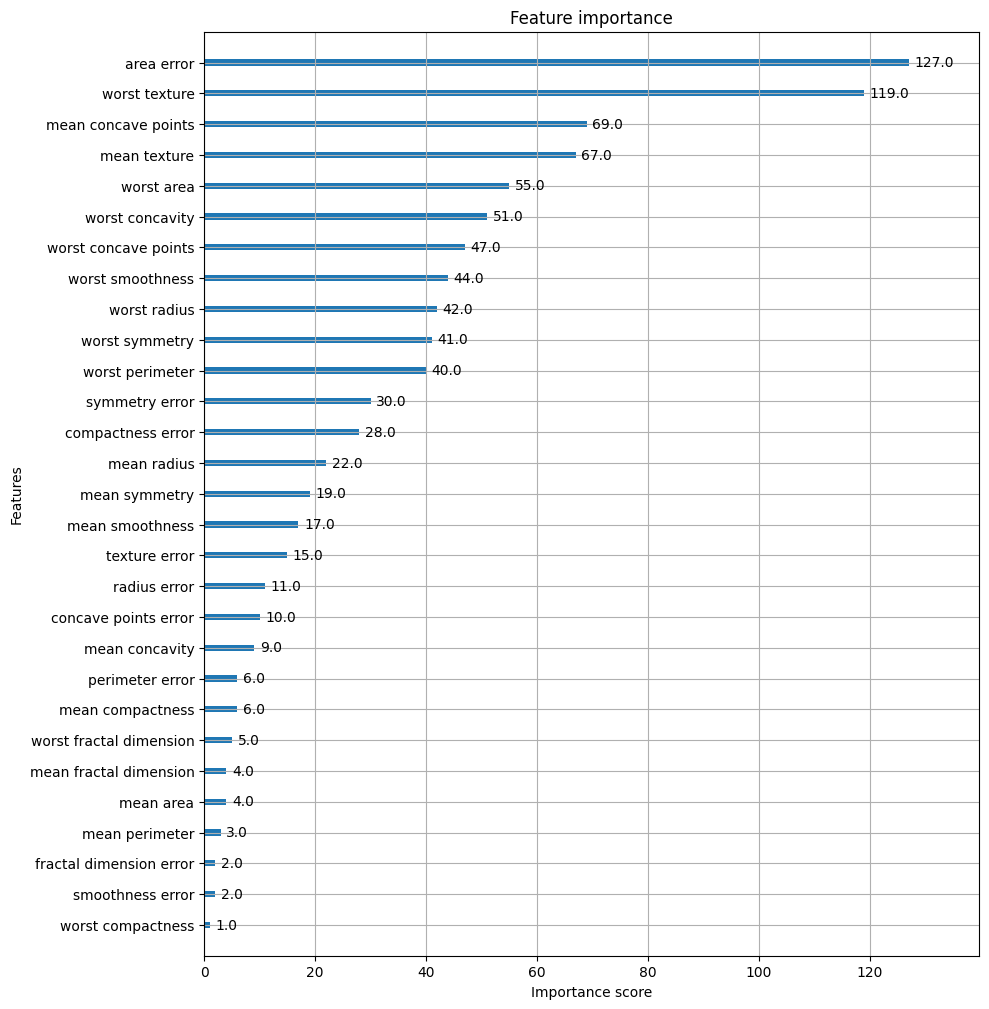

In [20]:
# xgboost 패키지에 내장된 시각화 기능 수행
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)

1) XGBoost 트리 시각화 (`to_graphviz`)
* 결정 트리처럼 XGBoost 모델의 트리 기반 규칙 구조도 시각화가 가능.
* **사용 API:** `xgboost.to_graphviz(학습된_모델_객체)`
* **주의사항:** 주피터 노트북(또는 코랩)에서 시각화하려면 사전에 **Graphviz** 프로그램과 파이썬 패키지가 설치되어 있어야 함.

---

2) XGBoost 교차 검증 (`cv`)
* 파이썬 래퍼 XGBoost는 사이킷런의 `GridSearchCV`처럼 교차 검증(Cross Validation)을 수행하여 최적의 파라미터를 찾을 수 있는 `cv()` API를 제공함.
* **반환값:** 결과는 **DataFrame** 형태로 반환됨.

**`cv()` 주요 파라미터**
* **`params`** (dict): 부스터 파라미터
* **`dtrain`** (DMatrix): 학습 데이터
* **`num_boost_round`** (int): 부스팅 반복 횟수
* **`nfold`** (int): CV 폴드 개수
* **`stratified`** (bool): CV 수행 시 층화 표본 추출(stratified sampling) 수행 여부
* **`metrics`** (string/list): CV 수행 시 모니터링할 성능 평가 지표
* **`early_stopping_rounds`** (int): 조기 중단을 활성화하기 위한 반복 횟수 지정

###사이킷런 래퍼 XGBoost의 개요 및 적용

In [21]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력.
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

In [22]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차행렬
[[34  3]
 [ 1 76]]
정확도:0.9649,정밀도:0.9620,재현율:0.9870,F1:0.9744, AUC:0.9530


In [25]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [26]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


In [27]:
# early_stopping_rounds를 10으로 설정하고 재학습.
xgb_wrapper=XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3,
                          early_stopping_rounds=10, eval_metric='logloss')
xgb_wrapper.fit(X_tr,y_tr, eval_set=evals, verbose=True)
ws10_preds=xgb_wrapper.predict(X_test)
ws10_preds_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_preds_proba)

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

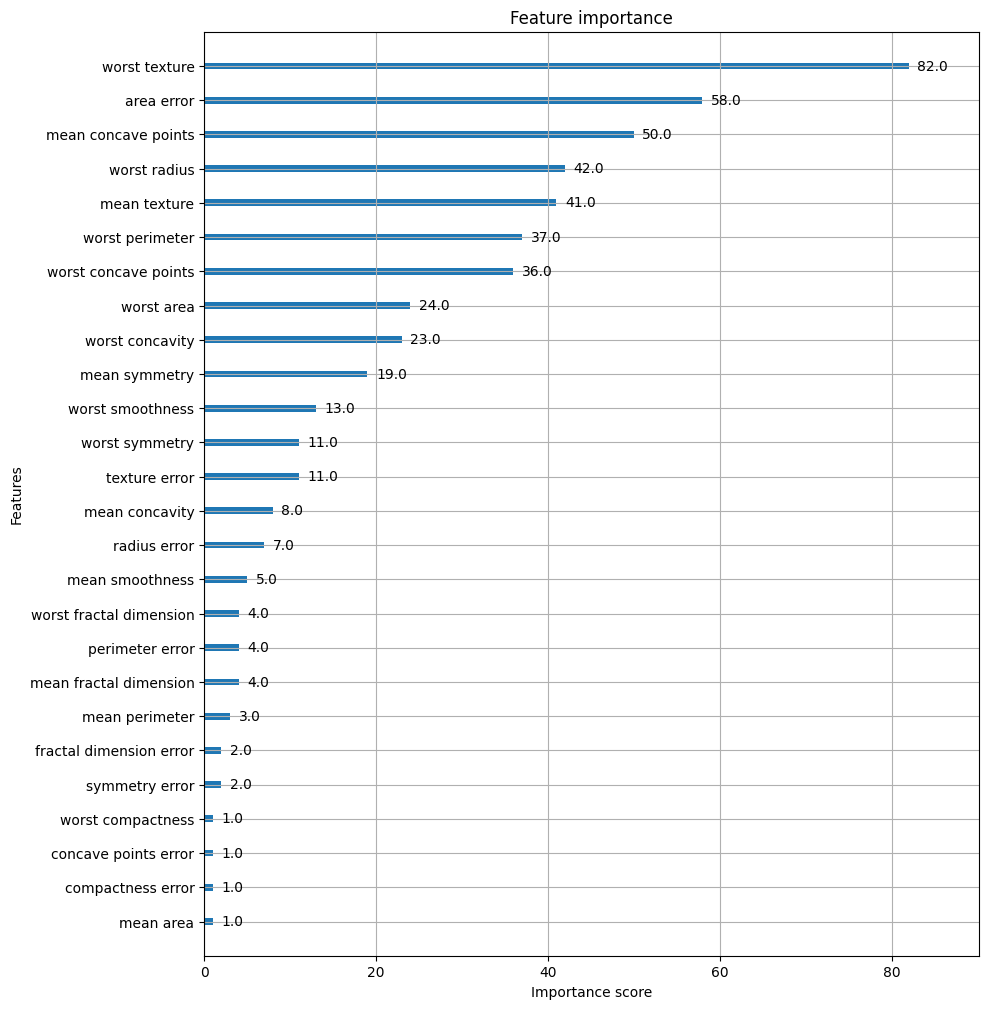

In [28]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
# 사이킷런 래퍼 클래스를 입력해도 무방.
plot_importance(xgb_wrapper, ax=ax)